## 1. Installing Dependencies

To ensure all necessary libraries are available for data processing, the Faker package is installed .



*  The Faker library is used to generate synthetic or dummy data, such as names, addresses, emails, and other structured data.
*   It is helpful for testing, simulating real-world scenarios, or handling missing data in datasets.



In [ ]:
!pip install faker


## 2. Importing Required Libraries

The following libraries are imported to facilitate data processing and analysis:

*   pandas: Used for data manipulation and analysis, providing functionalities to load, clean, and transform structured data efficiently.
*   numpy: Supports numerical operations and array-based computations, enhancing performance in data processing.

*  Faker: Generates synthetic (fake) data, such as names, addresses, emails, and more. This is useful for testing and handling missing values.






In [ ]:
import pandas as pd
import numpy as np
from faker import Faker

## 3. Loading the Dataset

The dataset used in this analysis is Faketucky, which was downloaded from GitHub. The following steps were taken to make it accessible in Google Colab:


1.   The Faketucky dataset (faketucky.dta) was downloaded from GitHub.
2.   The dataset was then uploaded to Google Colab using the Colab file upload feature.

1. The uploaded dataset was read into a Pandas DataFrame using the Stata file format (.dta)









In [ ]:
df = pd.read_stata("upload file")
df

In [ ]:
binary_columns = [col for col in df.columns if df[col].dropna().nunique() == 2 and set(df[col].dropna().unique()).issubset({0, 1})]
print("Binary Columns:", binary_columns)



In [ ]:
for col in binary_columns:
    print(f"Column: {col}, Data Type: {df[col].dtype}, Unique Values: {df[col].unique()}")


### 4. Filtering Data

A subset of the dataset is created where students enrolled in the first year:

In [ ]:
subset_data = df[(df['enroll_yr1_any'] == 1)]

In [ ]:
print(subset_data.shape)

In [ ]:
ct = pd.crosstab(subset_data['enroll_yr2_any'],columns='count')
ct

### 6. Handling Missing Values

 we handle missing values in the dataset by identifying and removing columns that have a high percentage of missing data. This helps ensure that only reliable and complete features remain for further analysis or machine learning tasks.

We Cleaned the DataFrame by removing columns with over 10% missing values and display the shape of the cleaned data.


In [ ]:
# #Calculate the percentage of missing values in each column
# missing_percentage = subset_data.isnull().sum() / len(subset_data) * 100

# #Identify columns with more than 10% missing values
# columns_to_drop = missing_percentage[missing_percentage > 10].index

# #Remove these columns from the DataFrame
# real_data_cleaned = subset_data.drop(columns=columns_to_drop)

# #Display the shape of the cleaned DataFrame to verify the changes
# real_data_cleaned.shape

Removed rows with over 10% missing values from the DataFrame, display its new shape, and print the cleaned data.


In [ ]:
# Calculate the percentage of missing values in each row
# missing_percentage_rows = real_data_cleaned.isnull().sum(axis=1) / len(real_data_cleaned.columns) * 100

# #dentify rows with less than 10% missing values (i.e., rows to keep)
# rows_to_drop = missing_percentage_rows[missing_percentage_rows > 10].index

# #Remove these rows from the DataFrame
# real_data_cleaned_new = real_data_cleaned.drop(index=rows_to_drop)

# #Display the shape of the cleaned DataFrame to verify the changes
# print('Shape after:', real_data_cleaned_new.shape)

# #Display the cleaned DataFrame
# print("\nCleaned DataFrame:\n", real_data_cleaned_new)


In [ ]:
# print(real_data_cleaned_new.isnull().sum()[real_data_cleaned_new.isnull().sum() > 0] / len(real_data_cleaned_new) * 100)

In [ ]:
# real_data_cleaned_new.dropna(inplace=True)
# real_data_cleaned_new


In [ ]:
# # Identify categorical and numeric columns
# categorical_columns = real_data_cleaned_new.select_dtypes(include=['object', 'category']).columns.tolist()
# numeric_columns = real_data_cleaned_new.select_dtypes(include=['int', 'float']).columns.tolist()

In [ ]:
# numeric_ranges = df[numeric_columns].agg(['min', 'max']).to_dict()


And created a dictionary with unique sorted values for each categorical column, excluding missing values.


In [ ]:
# categorical_values = {col: sorted(df[col].dropna().unique().tolist()) for col in categorical_columns}


Generated a synthetic DataFrame using random numeric values within observed ranges and random categorical selections.

In [ ]:
#   Generate synthetic data
#   num_rows = 36412
#   synthetic_data = []

# for _ in range(num_rows):
#     row = {}
#     # Generate numeric values within observed ranges
#     for col in numeric_ranges:  # Iterate through numeric column names
#         min_val = df[col].min()  # Get actual minimum value for the column
#         max_val = df[col].max()  # Get actual maximum value for the column
#         row[col] = np.random.uniform(min_val, max_val)

#     # Randomly select from categorical values
#     for col, values in categorical_values.items():
#         row[col] = np.random.choice(values) if values else None

#     synthetic_data.append(row)

# # Create a DataFrame
# synthetic_df = pd.DataFrame(synthetic_data)

Subset data where 'enroll_yr1_any' == 1, drop columns with >10% missing values, impute missing numeric values with mean, and save the cleaned dataset.


In [ ]:
# import pandas as pd

# # Load the dataset
# file_path = "/faketucky.dta"  # Update the file path as needed
# df = pd.read_stata(file_path)

# # Subset the data where enroll_yr1_any == 1
# df_subset = df[df["enroll_yr1_any"] == 1].copy()

# # Identify missing values percentage per column
# missing_percent = df_subset.isnull().mean()

# # Columns with more than 10% missing values
# cols_to_drop = missing_percent[missing_percent > 0.10].index.tolist()

# # Drop columns with more than 10% missing values
# df_cleaned = df_subset.drop(columns=cols_to_drop)

# # Impute missing values for remaining columns (less than 10% missing) using mean for numeric columns
# for col in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
#     if df_cleaned[col].isnull().sum() > 0:  # Only impute columns with missing values
#         df_cleaned[col].fillna(df_cleaned[col].mean(), inplace=True)

# # Save the cleaned dataset
# cleaned_file_path = "faketucky_cleaned.dta"  # Update the save path as needed
# df_cleaned.to_stata(cleaned_file_path)

# print(f"Cleaned dataset saved to {cleaned_file_path}")

Subset the data where 'enroll_yr1_any' == 1, drop columns with >80% missing values, impute missing numeric values with median/mean, use mode for categorical, and apply KNN imputation for remaining gaps, then save the cleaned dataset.

Error occurred due to KNNImputer being applied to non-numeric columns (e.g., 'Fake record');


In [ ]:
# import pandas as pd
# from sklearn.impute import KNNImputer

# # Load the dataset
# file_path = "/faketucky.dta"  # Update the file path
# df = pd.read_stata(file_path)

# # Step 1: Subset the data where enroll_yr1_any == 1
# df_subset = df[df["enroll_yr1_any"] == 1].copy()

# # Step 2: Identify missing values percentage per column
# missing_percent = df_subset.isnull().mean() * 100

# # Step 3: Drop columns with more than 80% missing values
# cols_to_drop = missing_percent[missing_percent > 80].index.tolist()
# df_cleaned = df_subset.drop(columns=cols_to_drop)

# # Step 4: Impute remaining missing values
# # - Numeric: Use median for skewed features, mean otherwise
# # - Categorical: Use mode (most frequent value)
# for col in df_cleaned.select_dtypes(include=['float64', 'int64',]).columns:
#     if df_cleaned[col].isnull().sum() > 0:
#         if df_cleaned[col].skew() > 1 or df_cleaned[col].skew() < -1:
#             df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)  # Use median if skewed
#         else:
#             df_cleaned[col].fillna(df_cleaned[col].mean(), inplace=True)  # Use mean if normal distribution

# for col in df_cleaned.select_dtypes(include=['object', 'category']).columns:
#     if df_cleaned[col].isnull().sum() > 0:
#         df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)  # Use mode for categorical

# # Step 5: Use KNN Imputation for remaining numerical gaps (optional)
# knn_imputer = KNNImputer(n_neighbors=5)
# df_cleaned.iloc[:, :] = knn_imputer.fit_transform(df_cleaned)

# # Save the cleaned dataset
# cleaned_file_path = "faketucky_cleaned_optimized.dta"
# df_cleaned.to_stata(cleaned_file_path)

# print(f"Optimized cleaned dataset saved to {cleaned_file_path}")

This code performs multiple steps to clean and impute missing data: it filters rows based on enrollment status, calculates missing data percentages, analyzes skewness of numeric columns, suggests appropriate imputation methods, and applies KNN imputation for numerical columns, before saving the cleaned dataset.

Error occurred due to KNNImputer being applied to non-numeric columns (e.g., 'Fake record'); fixed by applying it only to numeric columns.


In [ ]:
# import pandas as pd
# from sklearn.impute import KNNImputer

# # Load the dataset
# file_path = "/faketucky.dta"  # Update with actual file path
# df = pd.read_stata(file_path)

# # Step 1: Subset the data where enroll_yr1_any == 1
# df_subset = df[df["enroll_yr1_any"] == 1].copy()

# # Step 2: Identify missing values percentage per column
# missing_percentages = df_subset.isnull().mean() * 100

# # Step 3: Categorize variables by missingness
# low_missing_threshold = 30  # Define threshold for low missingness
# low_missing_vars = missing_percentages[missing_percentages < low_missing_threshold].reset_index()
# low_missing_vars.columns = ["Variable", "Missing_Percentage"]

# # Step 4: Get correct data types for these variables
# low_missing_vars["Data_Type"] = low_missing_vars["Variable"].apply(lambda x: str(df_subset[x].dtype))

# # Step 5: Analyze skewness for numerical columns
# skewness_info = {}

# for col in low_missing_vars["Variable"]:
#     if "float" in str(df_subset[col].dtype) or "int" in str(df_subset[col].dtype):  # Only for numeric columns
#         skewness_info[col] = df_subset[col].skew()
#     else:
#         skewness_info[col] = None  # Set None for categorical/string values

# # Convert skewness info to a DataFrame
# skewness_df = pd.DataFrame(list(skewness_info.items()), columns=["Variable", "Skewness"])

# # Step 6: Merge skewness with missing variable analysis
# low_missing_analysis = low_missing_vars.merge(skewness_df, on="Variable", how="left")

# # Step 7: Suggest imputation methods
# def suggest_imputation(row):
#     if "float" in row["Data_Type"] or "int" in row["Data_Type"]:  # Numeric
#         if row["Skewness"] is not None and (row["Skewness"] > 1 or row["Skewness"] < -1):
#             return "Median Imputation (Skewed)"
#         else:
#             return "Mean Imputation (Normally Distributed)"
#     elif "object" in row["Data_Type"] or "category" in row["Data_Type"]:  # Categorical/String
#         return "Mode Imputation (Most Frequent Category)"
#     else:
#         return "Check Data Type"

# # Apply imputation suggestion
# low_missing_analysis["Suggested_Imputation"] = low_missing_analysis.apply(suggest_imputation, axis=1)

# # Step 8: Drop columns with more than 80% missing values
# high_missing_threshold = 80
# cols_to_drop = missing_percentages[missing_percentages > high_missing_threshold].index.tolist()
# df_cleaned = df_subset.drop(columns=cols_to_drop)

# # Step 9: Separate numerical and categorical variables
# num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
# cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns

# # Step 10: Impute missing values
# for col in num_cols:
#     if df_cleaned[col].isnull().sum() > 0:
#         if df_cleaned[col].skew() > 1 or df_cleaned[col].skew() < -1:
#             df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)  # Median for skewed
#         else:
#             df_cleaned[col].fillna(df_cleaned[col].mean(), inplace=True)  # Mean for normal distribution

# for col in cat_cols:
#     if df_cleaned[col].isnull().sum() > 0:
#         df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)  # Mode for categorical

# # Step 11: Apply KNN Imputation for numerical columns only
# knn_imputer = KNNImputer(n_neighbors=5)
# df_cleaned[num_cols] = knn_imputer.fit_transform(df_cleaned[num_cols])

# # Step 12: Save the cleaned dataset
# cleaned_file_path = "faketucky_cleaned_optimized.dta"
# df_cleaned.to_stata(cleaned_file_path)

# print(f"Optimized cleaned dataset saved to {cleaned_file_path}")


### **Handling Missing Values :**



1. We calculated the percentage of missing values for each
column using .isnull().sum() / len(subset_data) * 100. This gave us a sense of how much data was missing in each column.

2. **Dropping Columns with Excessive Missing Data:** Explicitly, we dropped columns with more than 80% missing data. These columns were removed because they were considered too incomplete to provide meaningful insights or predictive power.

3.   **Imputation of Missing Values:**

*  **Numerical Data:** For numerical columns with missing
values, we decided to use imputation based on the distribution of the data:

    *  Columns with a high skew  (either positive or negative) were imputed using the median value, as this is more robust to outliers.
    *  Columns with a normal distribution were imputed using the mean value, assuming that the distribution of the data was not highly skewed.
*   **Categorical Data:** For categorical columns, we used the mode (most frequent value) to fill in missing data, as it reflects the most common category within that feature.


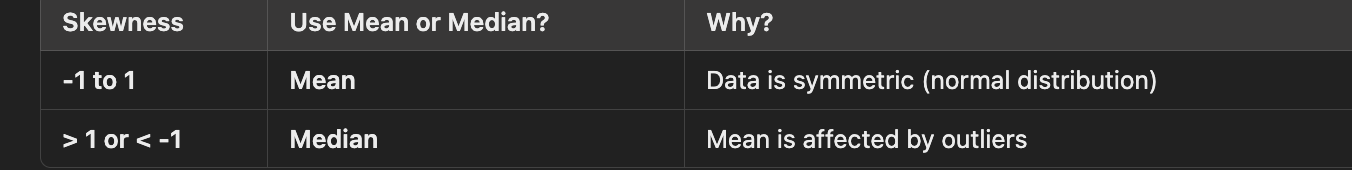




4.   **Applying KNN Imputation:**

The KNN imputation algorithm fills missing values by using the k nearest neighbors (rows) based on other features. The Income value for the row with the missing data is computed as the average of the Income values of the nearest rows (neighbors) with non-missing values.

We applied KNN imputation for numerical columns to fill in missing values based on the values of other similar data points.The KNNImputer() was used with 5 nearest neighbors (n_neighbors=5) to impute missing values in a more sophisticated manner, leveraging relationships between rows of the dataset.

5.  **Saving the Cleaned Data:**

   After processing the missing values, the cleaned dataset was saved to a new file named "faketucky_cleaned_optimized.dta" using .to_stata().

**why we have chosen this approach over first one for handling missing values?**



1.  Unlike the first code, which focuses on dropping columns with more than 10% missing data, this approach uses imputation to fill in missing values. This is beneficial because dropping columns can lead to data loss, especially when columns with only a small percentage of missing values are still important for analysis.
2.   This approach takes into account the skewness of numerical data. If a column is highly skewed, it uses the median to impute the missing values. The median is less affected by extreme outliers and better represents the central tendency in skewed distributions.

 For normally distributed data, mean imputation is used, which is appropriate when the data follows a bell-shaped curve.

3.   The KNN imputation technique is introduced to handle missing values in a more sophisticated manner. By using the KNN algorithm, we impute missing values based on the similarity between rows, which can lead to more accurate imputation compared to simple mean/median imputation. This is particularly important when the dataset has complex relationships between features.

4.  This approach allows us to **preserve the integrity of the dataset**. Rather than removing rows or columns that might contain valuable information, imputation helps to fill in missing values and ensure that the dataset remains as complete as possible.









In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# Load the dataset
file_path = "update with actual path"  
df = pd.read_stata(file_path)

# Step 1: Subset the data where enroll_yr1_any == 1
df_subset = df[df["enroll_yr1_any"] == 1].copy()

# Step 2: Identify missing values percentage per column
missing_percentages = df_subset.isnull().mean() * 100

# Step 3: Explicitly drop **all** columns with more than 80% missing values
columns_to_drop = [
    "ihe_avg_net_price_priv",
    "ihe_retention_lt_4_yr_full_time",
    "ihe_retention_lt_4_yr_part_time",
    "ihe_rate_lt_4_yr"
]
df_cleaned = df_subset.drop(columns=columns_to_drop, errors='ignore')

# Step 4: Separate numerical and categorical variables
num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns
binary_cols = [col for col in num_cols if df_cleaned[col].nunique() == 2]

# Step 5: Impute missing values
for col in num_cols:
    if df_cleaned[col].isnull().sum() > 0:
        if df_cleaned[col].skew() > 1 or df_cleaned[col].skew() < -1:
            df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)  # Median for skewed
        else:
            df_cleaned[col].fillna(df_cleaned[col].mean(), inplace=True)  # Mean for normal distribution

for col in cat_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)  # Mode for categorical

# Step 6: Apply KNN Imputation for numerical columns only
knn_imputer = KNNImputer(n_neighbors=5)
df_cleaned[num_cols] = knn_imputer.fit_transform(df_cleaned[num_cols])

# Step 8: Ensure binary columns are correctly imputed as 0 or 1
for col in binary_columns:
    # Fill NaNs with the most frequent value (mode)
    df[col] = df[col].fillna(df[col].mode()[0]).astype(int)

# Step 7: Save the cleaned dataset
cleaned_file_path = "faketucky_cleaned_optimized.dta"
df_cleaned.to_stata(cleaned_file_path)

print(f"✅ Optimized cleaned dataset saved to {cleaned_file_path}")


In [ ]:
df_cleaned

To display the total number of missing values (nulls) in the df_cleaned DataFrame after cleaning.

In [ ]:
print(df_cleaned.isnull().sum().sum())

The Faker library in Python is used to generate fake data for testing, development, or demonstration purposes.

In [ ]:
# Initialize Faker
fake = Faker()


## Generating Mock data

This code is designed to generate a synthetic dataset that mirrors the statistical properties and structure of an original dataset (df) for testing, modeling, or analysis.

  1. The first step is to understand the structure of the original dataset, specifically the types of variables it contains:
   
   **Categorical columns**: These columns hold non-numeric data, like categories or labels (e.g., "yes/no", "male/female").
   
   **Numeric columns**: These columns are further divided into integers and floating-point numbers (e.g., prices, measurements). Identifying these column types ensures that synthetic data is generated correctly for each type.


2.  **Defining Value Ranges and Categories**


*  **Range of numeric values:** For numeric columns, the minimum and maximum values are calculated. This helps ensure that the synthetic dataset remains within plausible boundaries.
*   **Unique categories for categorical columns:** For categorical columns, the unique values present in the original data are extracted, so that the synthetic dataset reflects the same variety of categories.


3.  **Generating the Synthetic Data**
Using Faker, the code generates synthetic rows that adhere to the following rules:


*  Integers are generated within the observed range (min to max) for each integer column, mimicking real-world values.
*  Floats are generated within their respective ranges, ensuring that continuous numeric data (like prices or scores) remains realistic.
*   Categorical data is drawn randomly from the unique categories in the original dataset, ensuring the synthetic data retains the same structure.


4. **Generating Multiple Rows**

 To mimic the original dataset's size, the code generates num_rows synthetic rows. This helps simulate a full dataset while maintaining the statistical characteristics of the original data.
5.   **Compiling the Data**

 After generating each synthetic row, the data is collected into a list and then transformed into a pandas DataFrame (synthetic_df). This makes it easier to use the generated data for analysis, model training, or testing.



























In [ ]:
import random
# Identify categorical and numeric columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
integer_columns = df.select_dtypes(include=['int8', 'int16', 'int32', 'int64']).columns.tolist()
float_columns = df.select_dtypes(include=['float64']).columns.tolist()

# Get value ranges for numeric columns
integer_ranges = {col: (df[col].min(), df[col].max()) for col in integer_columns if df[col].notna().any()}
float_ranges = {col: (df[col].min(), df[col].max()) for col in float_columns if df[col].notna().any()}

# Get unique values for categorical columns
categorical_values = {col: df[col].dropna().unique().tolist() for col in categorical_columns}

# Generate synthetic data
num_rows = 44442
synthetic_data = []

for _ in range(num_rows):
    row = {}

   # Generate integer values within observed ranges
    for col, (min_val, max_val) in integer_ranges.items():
        row[col] = fake.random_int(min=min_val, max=max_val)

    # Ensure binary columns stay as 0 or 1 and include both 0 and 1
    for col in binary_columns:
        if random.random() < 0.5:
            row[col] = 0
        else:
            row[col] = 1

    # Generate float values within observed ranges
    for col, (min_val, max_val) in float_ranges.items():
        row[col] = round(fake.pyfloat(min_value=min_val, max_value=max_val, right_digits=4), 4)

    # Randomly select from categorical values
    for col, values in categorical_values.items():
        row[col] = fake.random_element(values) if values else None

    synthetic_data.append(row)

# Create a new DataFrame
synthetic_df = pd.DataFrame(synthetic_data)

# Convert binary columns back to integers to ensure they remain 0 or 1
for col in binary_columns:
    synthetic_df[col] = synthetic_df[col].astype(int)


# Verify unique values of binary columns to ensure correctness
for col in binary_columns:
    print(f"{col} unique values: {synthetic_df[col].unique()}")

In [ ]:
synthetic_df

**Saving the Synthetic Dataset**

The generated synthetic data can be saved as a CSV file This allows the dataset to be shared, stored, or analyzed without compromising privacy or security concerns.



1. **Importing the Required Library:**

  The line from google.colab import files imports the files
  module from the google.colab library, which provides methods for file management, including downloading files in a Google Colab environment.

2. **Saving the DataFrame as a CSV File:**

 synthetic_df.to_csv("mock_faketucky.csv", index=False) saves the synthetic dataset (synthetic_df) as a CSV file.
The file is named **mock_faketucky.csv**


 3. **Initiating the Download:**

 files.download("mock_faketucky.csv") triggers the download of the saved CSV file. Once the command is executed, a download link is generated within the Colab environment, allowing the user to save the file directly to their local machine.







In [ ]:
unique_values =synthetic_df['enroll_yr1_2yr'].unique()
print(unique_values)